<a href="https://colab.research.google.com/github/thien2o7/AI/blob/main/nhandienkhuonmat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 1801 images belonging to 38 classes.
Found 446 images belonging to 38 classes.
Số lớp: 38
✅ Đã lưu class_labels.json


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🚀 Bắt đầu huấn luyện...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 698s 12s/step - accuracy: 0.2882 - loss: 2.8357 - val_accuracy: 0.0336 - val_loss: 5.1847 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 466ms/step - accuracy: 0.5480 - loss: 1.7454 - val_accuracy: 0.0359 - val_loss: 6.8170 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 476ms/step - accuracy: 0.6757 - loss: 1.2225 - val_accuracy: 0.0269 - val_loss: 11.4768 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 451ms/step - accuracy: 0.7624 - loss: 0.9562 - val_accuracy: 0.0448 - val_loss: 7.5061 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 458ms/step - accuracy: 0.7751 - loss: 0.8812 - val_accuracy: 0.0269 - val_loss: 18.0443 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 450ms/step - accuracy: 0.8484 - loss: 0.6142 - val_accuracy: 0.0516 - val_loss: 6.6205 - learning_rate: 5.0000e-04
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 462ms/step 

✅ Đã lưu mô hình vào face_recognition_cnn.h5


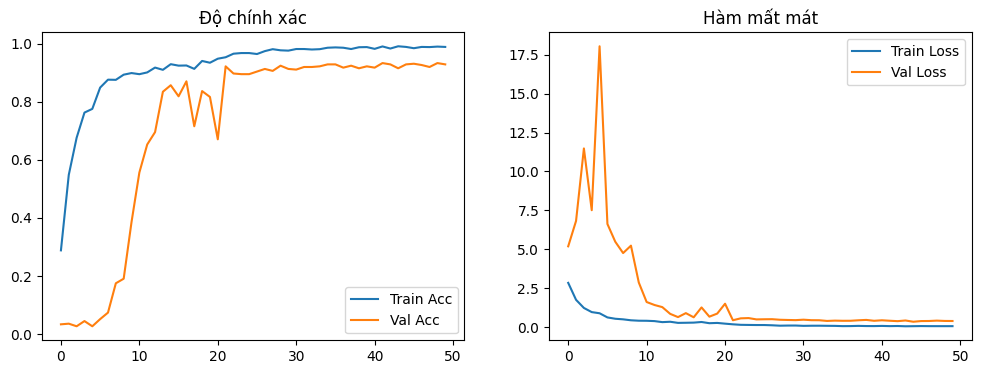

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import cv2
from mtcnn import MTCNN

# -------------------------------
# TIỀN XỬ LÝ: CẮT KHUÔN MẶT (chạy 1 lần)
# -------------------------------
def extract_face(img_path, target_size=(160, 160)):
    detector = MTCNN()
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)
    if len(results) == 0:
        return None
    x, y, w, h = results[0]['box']
    x, y = max(0, x), max(0, y)
    face = img_rgb[y:y+h, x:x+w]
    face = cv2.resize(face, target_size)
    return face

def prepare_face_dataset(original_dir, output_dir, target_size=(160, 160)):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    for person_name in os.listdir(original_dir):
        person_path = os.path.join(original_dir, person_name)
        if not os.path.isdir(person_path):
            continue
        save_path = os.path.join(output_dir, person_name)
        os.makedirs(save_path, exist_ok=True)
        for img_file in os.listdir(person_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_full = os.path.join(person_path, img_file)
                try:
                    face = extract_face(img_full, target_size)
                    if face is not None:
                        face_bgr = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)
                        cv2.imwrite(os.path.join(save_path, img_file), face_bgr)
                except Exception as e:
                    print(f"Lỗi {img_full}: {e}")
    print(f"✅ Đã tạo dữ liệu khuôn mặt tại {output_dir}")

# Cắt mặt (chỉ chạy 1 lần)
original_train_dir = "/content/drive/MyDrive/Ảnh selfie cho chiều t2 18 5"
face_dataset_dir = "/content/face_dataset_cnn"
# Bỏ comment dòng dưới nếu chưa cắt mặt lần nào:
# prepare_face_dataset(original_train_dir, face_dataset_dir, target_size=(160, 160))

# -------------------------------
# CHUẨN BỊ DỮ LIỆU
# -------------------------------
train_dir = face_dataset_dir if os.path.exists(face_dataset_dir) else original_train_dir
img_width, img_height = 160, 160
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# Lưu ánh xạ tên lớp
class_labels = {v: k for k, v in train_generator.class_indices.items()}
num_classes = len(class_labels)
print(f"Số lớp: {num_classes}")

# LƯU CLASS LABELS ra file để dùng sau
import json
with open('/content/class_labels.json', 'w', encoding='utf-8') as f:
    json.dump(class_labels, f, ensure_ascii=False)
print("✅ Đã lưu class_labels.json")

# -------------------------------
# XÂY DỰNG & HUẤN LUYỆN CNN
# -------------------------------
model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(img_width, img_height, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)

print("🚀 Bắt đầu huấn luyện...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

# -------------------------------
# LƯU MÔ HÌNH
# -------------------------------
model.save('/content/face_recognition_cnn.h5')
print("✅ Đã lưu mô hình vào face_recognition_cnn.h5")

# Vẽ biểu đồ
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Độ chính xác')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Hàm mất mát')
plt.legend()
plt.show()

✅ Đã tải mô hình
✅ Đã tải 38 lớp


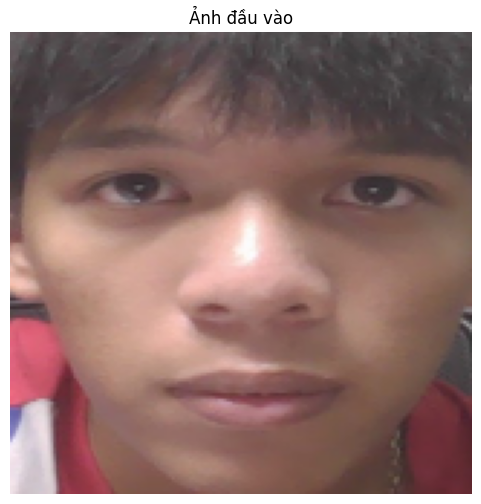


🎯 KẾT QUẢ NHẬN DIỆN:
  1. Phạm Minh Nhật: 24.66%
  2. Nguyễn Trọng Hữu: 23.21%
  3. Trần Trung Kiên: 12.47%

✅ Người dự đoán: Phạm Minh Nhật (độ tin cậy 24.66%)


'Phạm Minh Nhật'

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
import cv2
from mtcnn import MTCNN
import json


model = tf.keras.models.load_model('/content/face_recognition_cnn.h5')
print("✅ Đã tải mô hình")

with open('/content/class_labels.json', 'r', encoding='utf-8') as f:
    class_labels = json.load(f)
print(f"✅ Đã tải {len(class_labels)} lớp")

# -------------------------------
# HÀM CẮT KHUÔN MẶT
# -------------------------------
def extract_face(img_path, target_size=(160, 160)):
    detector = MTCNN()
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)
    if len(results) == 0:
        return None
    x, y, w, h = results[0]['box']
    x, y = max(0, x), max(0, y)
    face = img_rgb[y:y+h, x:x+w]
    face = cv2.resize(face, target_size)
    return face

# -------------------------------
# HÀM DỰ ĐOÁN
# -------------------------------
def predict_person(image_path, model, class_labels, target_size=(160,160)):
    # Cắt khuôn mặt
    face = extract_face(image_path, target_size)
    if face is None:
        print("⚠️ Không tìm thấy khuôn mặt, dùng ảnh gốc...")
        img = load_img(image_path, target_size=target_size)
        img_array = img_to_array(img)
    else:
        img_array = img_to_array(face)

    # Hiển thị ảnh
    plt.figure(figsize=(6,6))
    plt.imshow(img_array.astype('uint8'))
    plt.title("Ảnh đầu vào")
    plt.axis('off')
    plt.show()

    # Dự đoán
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)

    # Top 3 dự đoán
    top3_idx = np.argsort(pred[0])[-3:][::-1]
    print("\n🎯 KẾT QUẢ NHẬN DIỆN:")
    for i, idx in enumerate(top3_idx):
        person = class_labels[str(idx)]
        conf = pred[0][idx] * 100
        print(f"  {i+1}. {person}: {conf:.2f}%")

    pred_idx = top3_idx[0]
    person = class_labels[str(pred_idx)]
    confidence = pred[0][pred_idx] * 100
    print(f"\n✅ Người dự đoán: {person} (độ tin cậy {confidence:.2f}%)")
    return person


test_path = "/content/WIN_20260525_21_32_59_Pro.jpg"
predict_person(test_path, model, class_labels)
